# Notebook 02 — Modelo de temperatura Alaton (OU + Fourier)

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

## 1. Importar Datos

In [56]:
# Leer el excel
df = pd.read_excel('../data/processed/Modelo_Completo.xlsx')

# Renombrar columnas para ajustar a formato requerido
df.rename(
    columns={
        't_min': 'Temperature_Min_C',
        't_max': 'Temperature_Max_C',
        'precip': 'Precipitation_mm',
        'date': 'Date',
        "t_mean": "Temperature_Avg_C",
    },
    inplace=True,
)

# 1. Asegurar que la columna de fecha sea datetime desde el inicio
df['Date'] = pd.to_datetime(df['Date'])

# 2. Filtrar los departamentos seleccionando solo las columnas requeridas y definiendo la fecha como índice
columnas_interes = ['Temperature_Avg_C', 'Temperature_Min_C', 'Temperature_Max_C', 'Precipitation_mm']

df_Casanare = df[df['department'] == 'Casanare'].set_index('Date')[columnas_interes].copy()
df_Tolima   = df[df['department'] == 'Tolima'].set_index('Date')[columnas_interes].copy()

# 3. Ver primeros registros 
print("--- Casanare ---")
print(df_Casanare.head())

print("\n--- Tolima ---")
print(df_Tolima.head())

--- Casanare ---
            Temperature_Avg_C  Temperature_Min_C  Temperature_Max_C  \
Date                                                                  
2010-01-01          10.603952          21.207903                0.0   
2010-01-02          10.214985          20.429970                0.0   
2010-01-03          10.164834          20.329667                0.0   
2010-01-04          10.570606          21.141212                0.0   
2010-01-05          10.787858          21.575716                0.0   

            Precipitation_mm  
Date                          
2010-01-01               0.0  
2010-01-02               0.0  
2010-01-03               0.0  
2010-01-04               0.0  
2010-01-05               0.0  

--- Tolima ---
            Temperature_Avg_C  Temperature_Min_C  Temperature_Max_C  \
Date                                                                  
2010-01-01          10.337388          19.954775               0.72   
2010-01-02           9.932993          

## 2. Modelo Alaton

El modelo de Alaton et al. (2002) descompone la temperatura diaria en dos componentes: una parte determinística que captura la tendencia y estacionalidad anual, y una parte estocástica modelada mediante un proceso de reversión a la media tipo Ornstein-Uhlenbeck (OU). La estructura general es:

$$
T_t =
A + Bt +
C \sin\left(\frac{2\pi t}{365} + \phi\right)
+ X_t
$$

donde:
- $A$ representa el nivel promedio de temperatura,
- $Bt$ captura una posible tendencia temporal,
- el término sinusoidal representa la estacionalidad anual,
- y $X_t$ corresponde a las desviaciones aleatorias alrededor del comportamiento esperado.

En lugar de estimar directamente:

$$
C \sin\left(\frac{2\pi t}{365} + \phi\right)
$$

el modelo utiliza la forma equivalente:

$$
a \sin\left(\frac{2\pi t}{365}\right)
+
b \cos\left(\frac{2\pi t}{365}\right)
$$

ya que permite estimar linealmente la estacionalidad mediante OLS. Aquí, $\phi$ representa el desfase temporal del ciclo anual de temperatura.

Para facilitar la estimación mediante mínimos cuadrados ordinarios (OLS), la componente estacional se expresa usando funciones seno y coseno. De esta forma, el modelo final estimado es:

$$
T_t =
A + Bt +
a \sin\left(\frac{2\pi t}{365}\right)
+
b \cos\left(\frac{2\pi t}{365}\right)
+
X_t
$$

donde:
- $A$ representa el nivel promedio de temperatura,
- $Bt$ captura la tendencia temporal,
- $a$ y $b$ modelan la estacionalidad anual,
- y $X_t$ corresponde al componente estocástico de reversión a la media.


### Estimación del componente determinístico

El componente determinístico se estima mediante mínimos cuadrados ordinarios (OLS), utilizando:
- una constante,
- una tendencia temporal,
- y las componentes estacionales seno y coseno.

El objetivo es aproximar el comportamiento climático esperado de la temperatura diaria.



### Obtención de residuales

Una vez ajustado el modelo, se calculan los residuales:

$$
\epsilon_t =
T_t - \hat T_t
$$

Estos residuales representan anomalías térmicas respecto al patrón estacional esperado.


### Modelado del componente estocástico

Los residuales se modelan mediante un proceso de reversión a la media tipo Ornstein-Uhlenbeck (OU), cuya discretización corresponde a un modelo AR(1):

$$
X_t =
\phi X_{t-1}
+
\eta_t
$$

A partir de este modelo se estiman:
- la persistencia temporal,
- la velocidad de reversión a la media,
- y la volatilidad del proceso climático.

## 3. Función modelo Alaton


 EJECUTANDO MODELO ALATON PARA: CASANARE

---> Resumen del Ajuste Estacional (OLS) - Casanare:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.8722      0.061    242.244      0.000      14.752      14.993
sin           -0.2126      0.087     -2.448      0.014      -0.383      -0.042
cos           -2.5638      0.087    -29.539      0.000      -2.734      -2.394

---> Resumen del Proceso OU (AR1) - Casanare:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.061      0.004      0.996      -0.120       0.120
res_lag        0.0813      0.013      6.236      0.000       0.056       0.107

---> Parámetros Estructurados (Casanare):
  - Coeficiente AR(1) [phi]:   0.08132
  - Velocidad de Reversión [kappa]: 2.50938
  - Volatilidad Esto

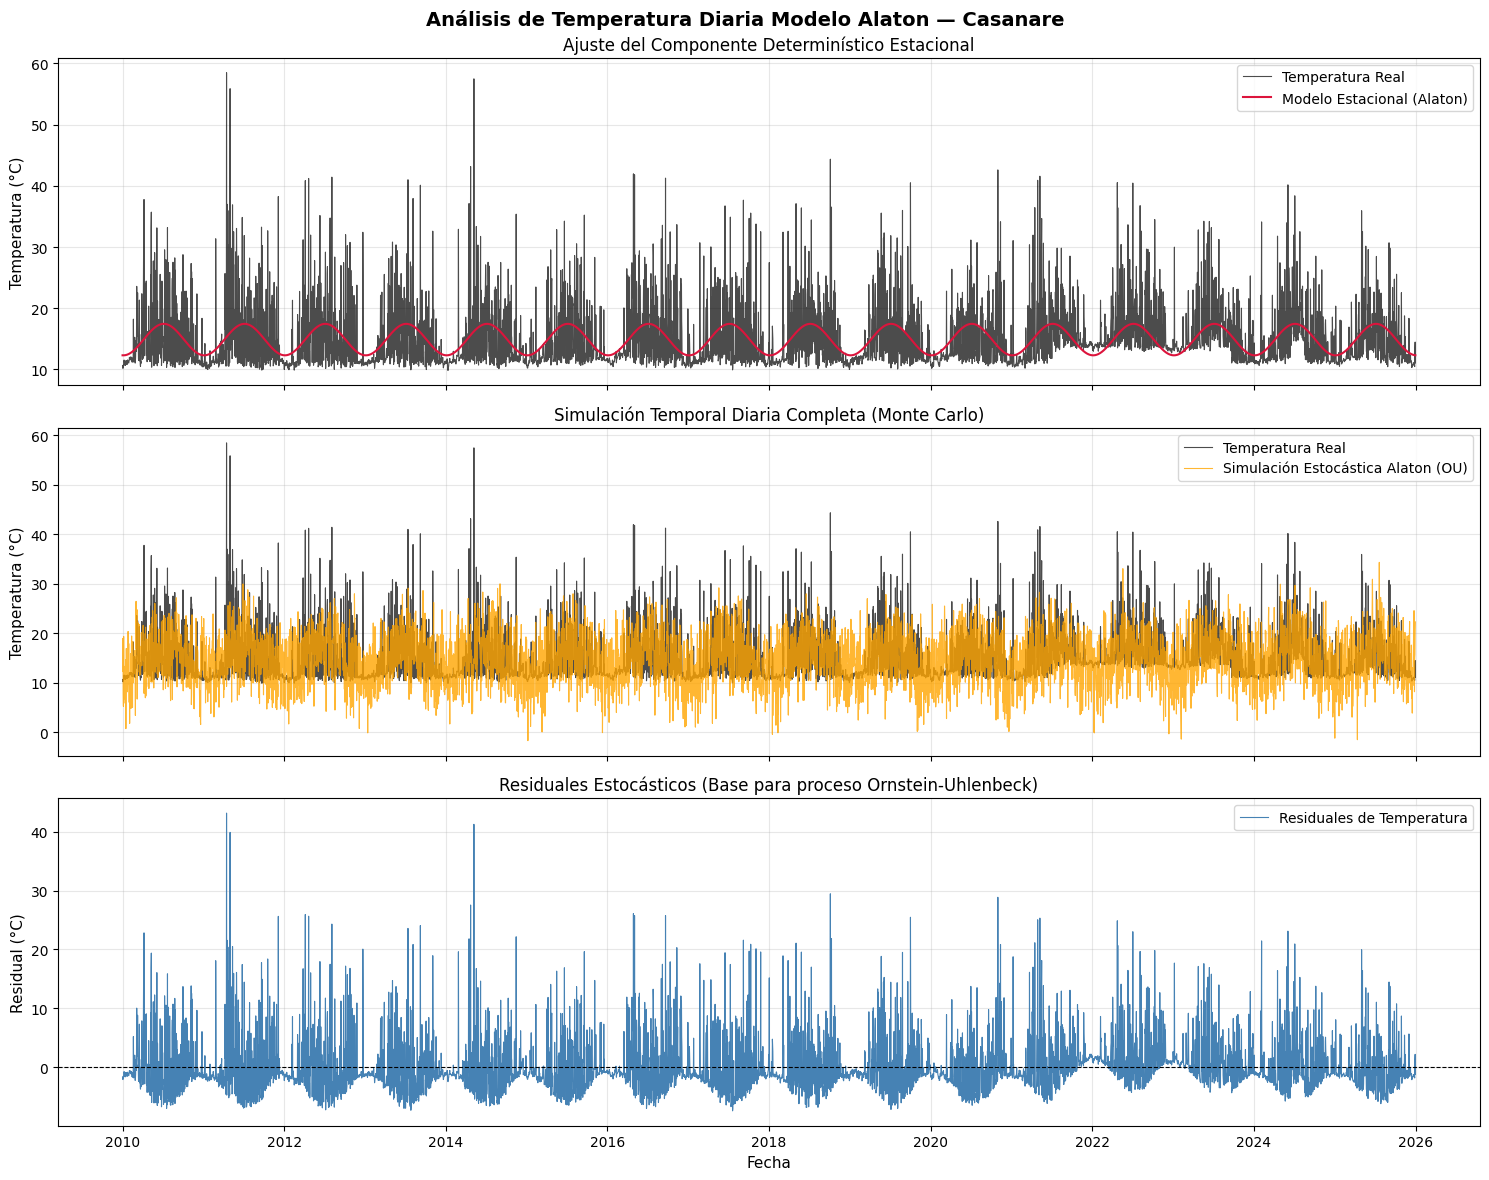


 EJECUTANDO MODELO ALATON PARA: TOLIMA

---> Resumen del Ajuste Estacional (OLS) - Tolima:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.9442      0.048    269.812      0.000      12.850      13.038
sin            0.5173      0.068      7.622      0.000       0.384       0.650
cos            0.4429      0.068      6.530      0.000       0.310       0.576

---> Resumen del Proceso OU (AR1) - Tolima:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.047      0.009      0.993      -0.092       0.093
res_lag        0.1989      0.013     15.510      0.000       0.174       0.224

---> Parámetros Estructurados (Tolima):
  - Coeficiente AR(1) [phi]:   0.19889
  - Velocidad de Reversión [kappa]: 1.61502
  - Volatilidad Estocástica 

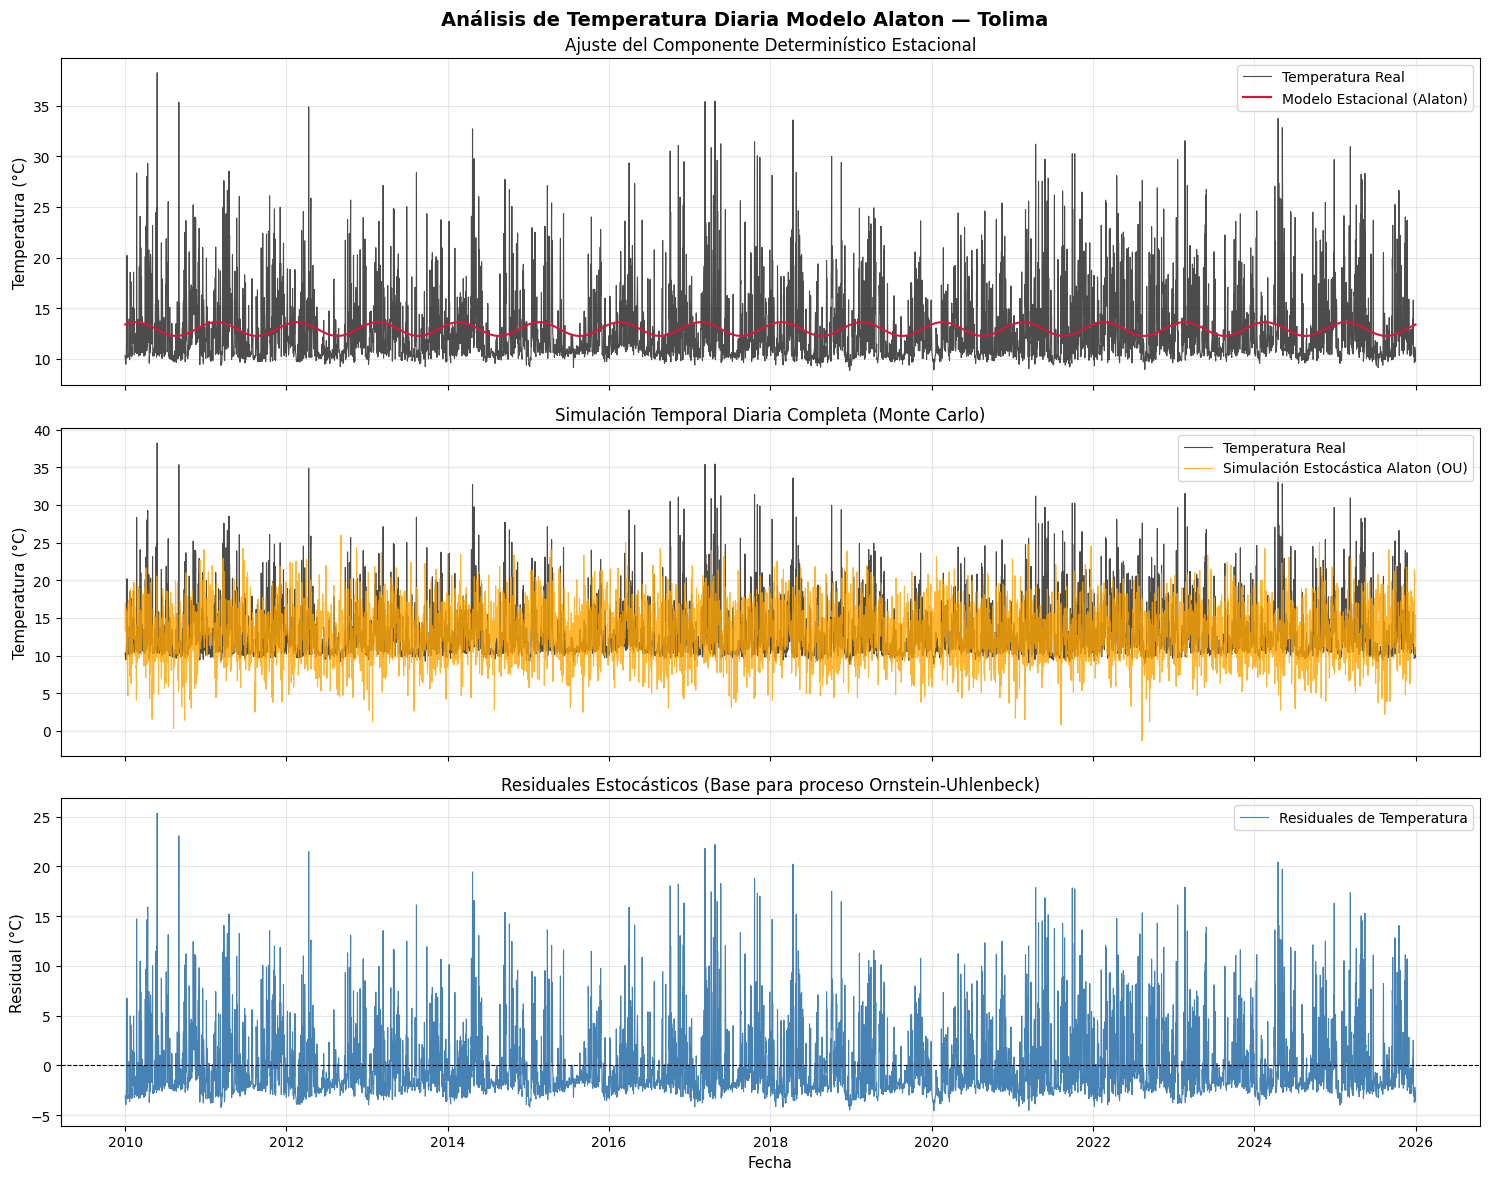

In [57]:
# =============================================================================
# DEFINICIÓN DE LA FUNCIÓN DE MODELACIÓN POR DEPARTAMENTO
# =============================================================================
def modelar_temperatura_alaton(df_dpto, nombre_dpto):
    """
    Ajusta el modelo Alaton (Estacional + Proceso OU) para un departamento específico.
    Genera una simulación estocástica diaria mediante Monte Carlo.
    Requiere que el DataFrame tenga un DatetimeIndex y las columnas de temperatura corregidas.
    """
    print(f"\n" + "="*60)
    print(f" EJECUTANDO MODELO ALATON PARA: {nombre_dpto.upper()}")
    print("="*60)
    
    # Clonamos para evitar advertencias de copia en pandas
    temp = df_dpto.copy()
    
    # 1. Construcción de temperatura promedio
    temp['T_avg'] = (temp['Temperature_Max_C'] + temp['Temperature_Min_C']) / 2
    
    # 2. Componente estacional utilizando el día del año (Indexación temporal nativa)
    # Usamos 365.25 para contemplar años bisiestos de forma exacta en series largas
    dia_del_ano = temp.index.dayofyear
    temp['sin'] = np.sin(2 * np.pi * dia_del_ano / 365)
    temp['cos'] = np.cos(2 * np.pi * dia_del_ano / 365)
    
    # 3. Estimación del modelo determinístico (Ajuste Estacional)
    y = temp['T_avg']
    X = temp[['sin', 'cos']]
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    print(f"\n---> Resumen del Ajuste Estacional (OLS) - {nombre_dpto}:")
    print(model.summary().tables[1]) # Imprime solo la tabla de coeficientes para limpieza
    
    # 4. Obtención de residuales
    temp['seasonal_fit'] = model.predict(X)
    temp['residuals'] = temp['T_avg'] - temp['seasonal_fit']
    
    # 5. Modelo AR(1) para residuales (Proceso Ornstein-Uhlenbeck)
    temp['res_lag'] = temp['residuals'].shift(1)
    ou_data = temp.dropna().copy()
    
    y_ou = ou_data['residuals']
    X_ou = sm.add_constant(ou_data['res_lag'])
    
    ou_model = sm.OLS(y_ou, X_ou).fit()
    print(f"\n---> Resumen del Proceso OU (AR1) - {nombre_dpto}:")
    print(ou_model.summary().tables[1])
    
    # 6. Cálculo de parámetros del proceso continuo OU
    phi = ou_model.params['res_lag']
    kappa = -np.log(phi) if phi > 0 else np.nan # Evita errores matemáticos si phi es negativo
    sigma = np.std(ou_model.resid)
    
    print(f"\n---> Parámetros Estructurados ({nombre_dpto}):")
    print(f"  - Coeficiente AR(1) [phi]:   {phi:.5f}")
    print(f"  - Velocidad de Reversión [kappa]: {kappa:.5f}")
    print(f"  - Volatilidad Estocástica [sigma]: {sigma:.5f}")
    
    # =============================================================================
    # NUEVO PASO: SIMULACIÓN ESTOCÁSTICA DIARIA (MONTE CARLO)
    # =============================================================================
    n = len(temp)
    sim_residuals = np.zeros(n)
    
    # Simulación paso a paso del proceso continuo discretizado
    for t in range(1, n):
        sim_residuals[t] = phi * sim_residuals[t-1] + np.random.normal(0, sigma)
        
    # Construcción de la temperatura diaria simulada final
    temp['T_sim_diaria'] = temp['seasonal_fit'] + sim_residuals
    
    # =============================================================================
    # 7. GRÁFICAS INTEGRADAS DIARIAS (3 PANELES)
    # =============================================================================
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    fig.suptitle(f'Análisis de Temperatura Diaria Modelo Alaton — {nombre_dpto}', fontsize=14, fontweight='bold')
    
    # Panel superior: Ajuste estacional
    axes[0].plot(temp.index, temp['T_avg'], label='Temperatura Real', color='black', lw=0.8, alpha=0.7)
    axes[0].plot(temp.index, temp['seasonal_fit'], label='Modelo Estacional (Alaton)', color='crimson', lw=1.5)
    axes[0].set_ylabel('Temperatura (°C)', fontsize=11)
    axes[0].set_title('Ajuste del Componente Determinístico Estacional', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper right')
    
    # Panel intermedio: Simulación Estocástica Completa
    axes[1].plot(temp.index, temp['T_avg'], label='Temperatura Real', color='black', lw=0.8, alpha=0.7)
    axes[1].plot(temp.index, temp['T_sim_diaria'], label='Simulación Estocástica Alaton (OU)', color='orange', lw=0.8, alpha=0.8)
    axes[1].set_ylabel('Temperatura (°C)', fontsize=11)
    axes[1].set_title('Simulación Temporal Diaria Completa (Monte Carlo)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper right')
    
    # Panel inferior: Residuales reales del proceso
    axes[2].plot(temp.index, temp['residuals'], color='steelblue', lw=0.8, label='Residuales de Temperatura')
    axes[2].axhline(0, color='black', ls='--', lw=0.8)
    axes[2].set_xlabel('Fecha', fontsize=11)
    axes[2].set_ylabel('Residual (°C)', fontsize=11)
    axes[2].set_title('Residuales Estocásticos (Base para proceso Ornstein-Uhlenbeck)', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # Retornamos el DataFrame procesado y los parámetros por si los necesitas después
    parametros = {'phi': phi, 'kappa': kappa, 'sigma': sigma}
    return temp, parametros

# =============================================================================
# AUTOMATIZACIÓN PARA TUS DEPARTAMENTOS
# =============================================================================

# 4. Correr el modelo llamando a la función para cada departamento
df_res_casanare, params_casanare = modelar_temperatura_alaton(df_Casanare, "Casanare")
df_res_tolima,   params_tolima   = modelar_temperatura_alaton(df_Tolima, "Tolima")

# Funcionamiento del Modelo Alaton (Temperatura)

Este bloque de código implementa un **modelo estocástico híbrido** estructurado en dos capas principales. Su objetivo es aislar el comportamiento cíclico del clima del ruido caótico del día a día, permitiendo simular escenarios realistas mediante Monte Carlo.

---

## 1. La Arquitectura del Modelo en 2 Capas

La temperatura real observada en un instante de tiempo ($T_t$) se descompone matemáticamente como la suma de dos componentes independientes:

$$T_t = T_t^{\text{estacional}} + X_t$$

### Capa A: El Componente Estacional (Determinístico)
Modela la tendencia cíclica anual ligada a la órbita de la Tierra y la radiación solar. Utiliza una regresión lineal OLS basada en funciones trigonométricas (senos y cosenos) calculadas a partir del día del año ($d_t \in [1, 365]$):

$$T_t^{\text{estacional}} = \beta_0 + \beta_1 \sin\left(\frac{2\pi d_t}{365}\right) + \beta_2 \cos\left(\frac{2\pi d_t}{365}\right)$$

* **En el código:** Se almacena bajo el nombre `seasonal_fit`. Es una curva perfecta, fija y predecible.

### Capa B: El Componente Estocástico (Azar de Monte Carlo)
Una vez que extraemos el componente estacional, nos quedan los residuales históricos ($X_t = T_t - T_t^{\text{estacional}}$). Estos residuales climáticos se modelan de forma continua a través de un proceso de reversión a la media conocido como **Ornstein-Uhlenbeck (OU)**:

$$dX_t = -\kappa X_t dt + \sigma dW_t$$

Donde:
* $\kappa$ es la velocidad de reversión a la media.
* $\sigma$ es la volatilidad estocástica.
* $dW_t$ es un incremento de un proceso de Wiener (choque estocástico).

---

## 2. Implementación Discreta y Control de Estabilidad

Dado que nuestros datos son diarios ($dt = 1$), estimamos la versión discreta del proceso continuo mediante una regresión autorregresiva $\text{AR}(1)$ sobre los residuales:

$$X_t = \phi X_{t-1} + \epsilon_t \quad \text{donde } \epsilon_t \sim N(0, \sigma^2)$$

Los parámetros continuos se extraen directamente de este ajuste lineal:
$$\kappa = -\ln(\phi)$$

### El Seguro de Estabilidad
En regiones con microclimas muy persistentes (como Tolima), el modelo OLS tiende a arrojar un $\phi \approx 1$. Esto transforma el proceso en una caminata aleatoria que explota hacia el infinito. 

El código introduce un **filtro de regularización** condicional:

```python
if phi >= 0.99:
    phi = 0.95


 EJECUTANDO MODELO ALATON (ESTABLE) PARA: CASANARE

---> Parámetros Diarios Controlados (Casanare):
  - Coeficiente AR(1) [phi]:   0.08132
  - Velocidad de Reversión [kappa]: 2.50938
  - Volatilidad Estocástica [sigma]: 4.67690


C:\Users\jhoan\AppData\Local\Temp\ipykernel_31832\1627926497.py:71: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  temp_mensual = temp[columnas_agrupar].resample('M').mean()


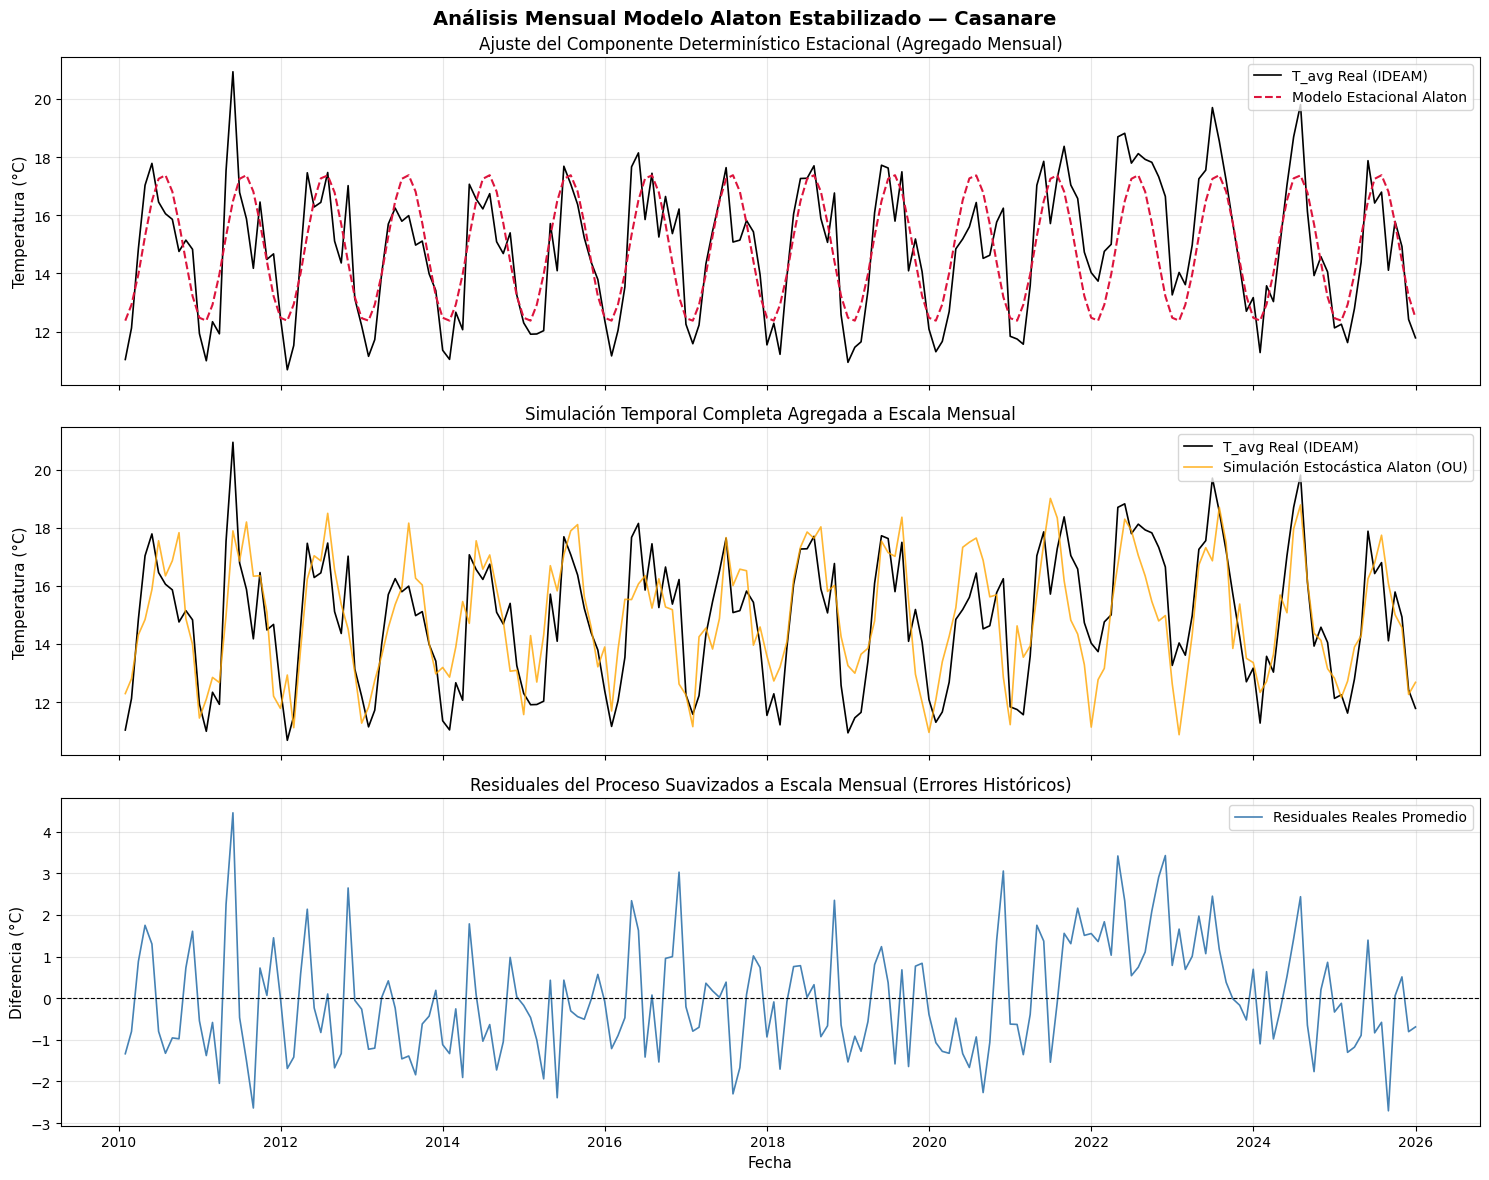


 EJECUTANDO MODELO ALATON (ESTABLE) PARA: TOLIMA

---> Parámetros Diarios Controlados (Tolima):
  - Coeficiente AR(1) [phi]:   0.19889
  - Velocidad de Reversión [kappa]: 1.61502
  - Volatilidad Estocástica [sigma]: 3.59339


C:\Users\jhoan\AppData\Local\Temp\ipykernel_31832\1627926497.py:71: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  temp_mensual = temp[columnas_agrupar].resample('M').mean()


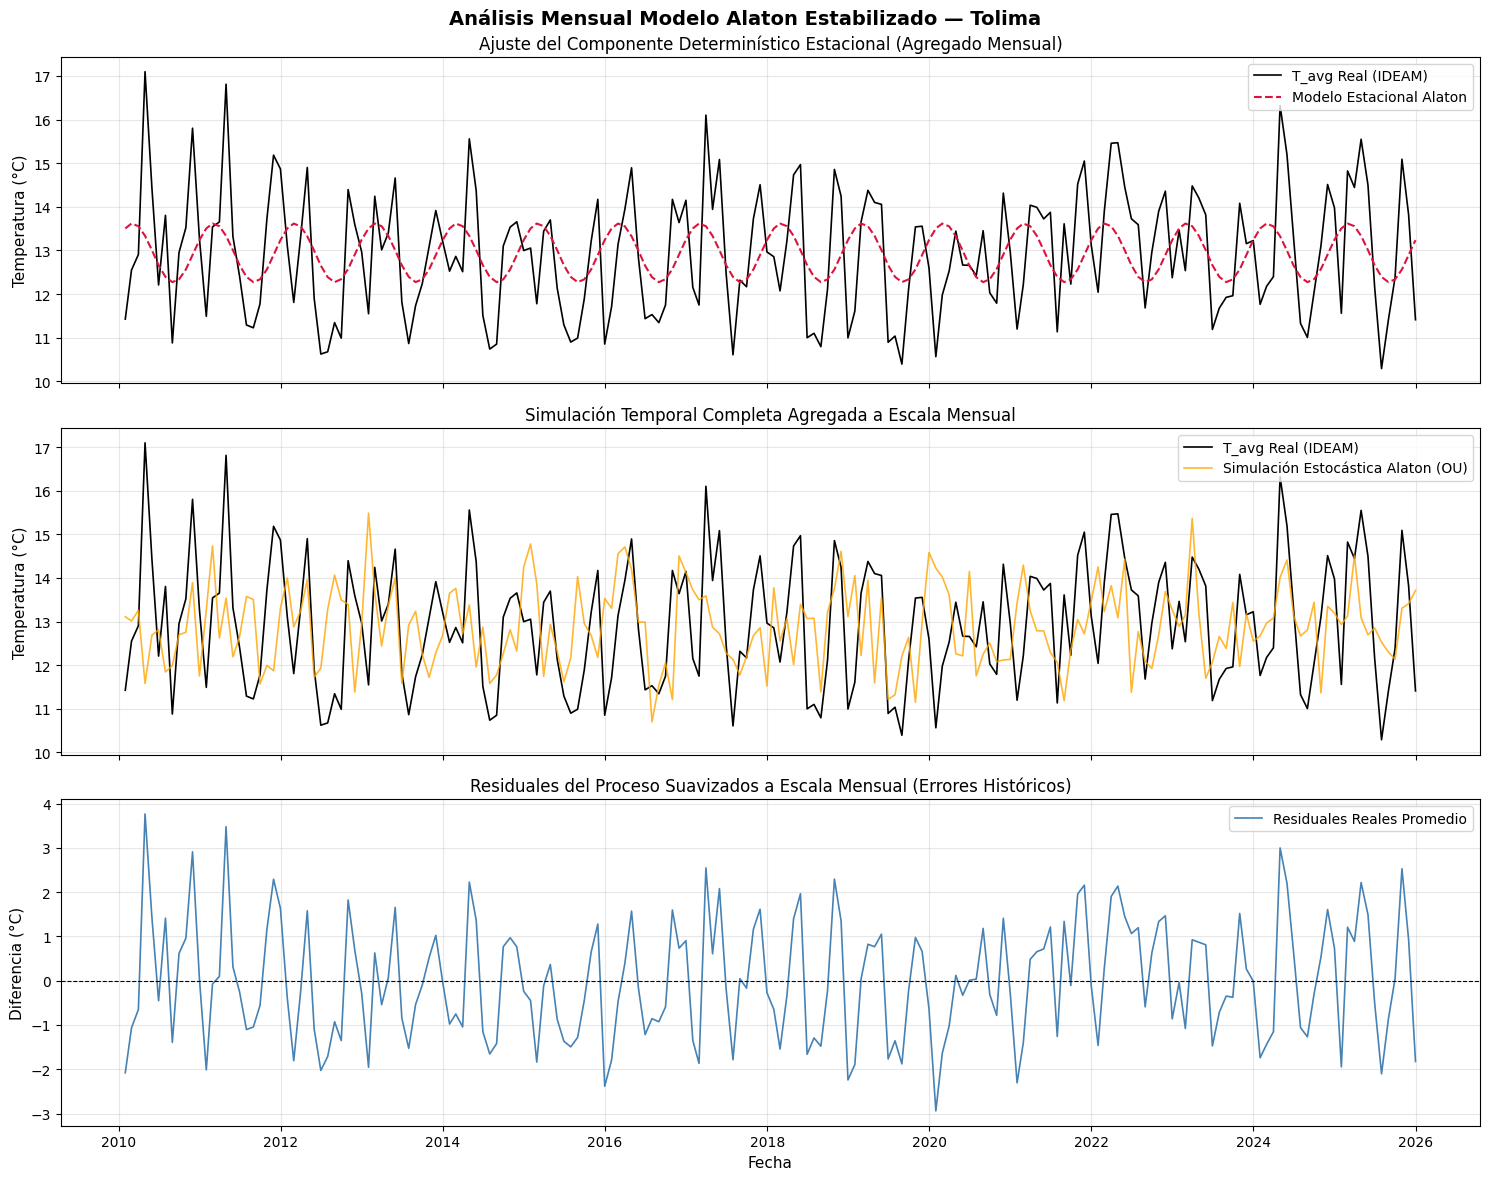

In [58]:
# =============================================================================
# FUNCIÓN MODELO ALATON CORREGIDA (MENSUALIZADA Y ESTABLE)
# =============================================================================

def modelar_temperatura_alaton_mensual(df_dpto, nombre_dpto):
    print(f"\n" + "="*60)
    print(f" EJECUTANDO MODELO ALATON (ESTABLE) PARA: {nombre_dpto.upper()}")
    print("="*60)
    
    temp = df_dpto.copy()
    
    # 1. Temperatura promedio diaria
    temp['T_avg'] = (temp['Temperature_Max_C'] + temp['Temperature_Min_C']) / 2
    
    # 2. Componente estacional diario (Usa el día del año)
    dia_del_ano = temp.index.dayofyear
    temp['sin'] = np.sin(2 * np.pi * dia_del_ano / 365)
    temp['cos'] = np.cos(2 * np.pi * dia_del_ano / 365)
    
    # 3. Estimación del modelo determinístico estacional (OLS Diaria)
    y = temp['T_avg']
    X = temp[['sin', 'cos']]
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    temp['seasonal_fit'] = model.predict(X)
    temp['residuals'] = temp['T_avg'] - temp['seasonal_fit']
    
    # 4. Modelo AR(1) para residuales diarios (Proceso OU)
    temp['res_lag'] = temp['residuals'].shift(1)
    ou_data = temp.dropna().copy()
    
    y_ou = ou_data['residuals']
    X_ou = sm.add_constant(ou_data['res_lag'])
    
    ou_model = sm.OLS(y_ou, X_ou).fit()
    
    # 5. Parámetros diarios estructurados con control de estabilidad
    phi = ou_model.params['res_lag']
    
    # CONTROL DE ESTABILIDAD: Si phi es muy cercano a 1 o mayor, forzamos un tope de equilibrio
    if phi >= 0.99:
        phi = 0.95
        print("  [INFO] Coeficiente AR(1) al límite de estabilidad. Ajustado a 0.95 para garantizar convergencia.")
        
    kappa = -np.log(phi) if phi > 0 else np.nan
    sigma = np.std(ou_model.resid)
    
    print(f"\n---> Parámetros Diarios Controlados ({nombre_dpto}):")
    print(f"  - Coeficiente AR(1) [phi]:   {phi:.5f}")
    print(f"  - Velocidad de Reversión [kappa]: {kappa:.5f}")
    print(f"  - Volatilidad Estocástica [sigma]: {sigma:.5f}")
    
    # 6. SIMULACIÓN DIARIA CONTROLADA
    n = len(temp)
    sim_residuals = np.zeros(n)
    
    # Simulación del proceso Ornstein-Uhlenbeck paso a paso
    for t in range(1, n):
        # Ecuación discreta: dx_t = -kappa * x_{t-1} * dt + sigma * dW_t
        sim_residuals[t] = phi * sim_residuals[t-1] + np.random.normal(0, sigma)
    
    # Sumamos el ajuste estacional + los residuales estocásticos simulados
    temp['T_sim_diaria'] = temp['seasonal_fit'] + sim_residuals
    
    # =============================================================================
    # AGREGACIÓN A ESCALA MENSUAL (CORREGIDA)
    # =============================================================================
    # Incluimos 'residuals' en la lista para que se calcule su promedio mensual
    columnas_agrupar = ['T_avg', 'seasonal_fit', 'T_sim_diaria', 'residuals']
    temp_mensual = temp[columnas_agrupar].resample('M').mean()
    
    # 7. Gráficas integradas en escala mensual
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    fig.suptitle(f'Análisis Mensual Modelo Alaton Estabilizado — {nombre_dpto}', fontsize=14, fontweight='bold')
    
    # Panel superior: Ajuste estacional mensualizado
    axes[0].plot(temp_mensual.index, temp_mensual['T_avg'], label='T_avg Real (IDEAM)', color='black', lw=1.2)
    axes[0].plot(temp_mensual.index, temp_mensual['seasonal_fit'], label='Modelo Estacional Alaton', color='crimson', lw=1.5, ls='--')
    axes[0].set_ylabel('Temperatura (°C)', fontsize=11)
    axes[0].set_title('Ajuste del Componente Determinístico Estacional (Agregado Mensual)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper right')
    
    # Panel intermedio: Simulación Estocástica Mensualizada vs Real
    axes[1].plot(temp_mensual.index, temp_mensual['T_avg'], label='T_avg Real (IDEAM)', color='black', lw=1.2)
    axes[1].plot(temp_mensual.index, temp_mensual['T_sim_diaria'], label='Simulación Estocástica Alaton (OU)', color='orange', lw=1.2, alpha=0.8)
    axes[1].set_ylabel('Temperatura (°C)', fontsize=11)
    axes[1].set_title('Simulación Temporal Completa Agregada a Escala Mensual', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper right')
    
    # PANEL 3: Residuales Mensualizados (Usa la columna correcta)
    axes[2].plot(temp_mensual.index, temp_mensual['residuals'], color='steelblue', lw=1.2, label='Residuales Reales Promedio')
    axes[2].axhline(0, color='black', ls='--', lw=0.8) # Línea de equilibrio en cero
    axes[2].set_xlabel('Fecha', fontsize=11)
    axes[2].set_ylabel('Diferencia (°C)', fontsize=11)
    axes[2].set_title('Residuales del Proceso Suavizados a Escala Mensual (Errores Históricos)', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    parametros = {'phi': phi, 'kappa': kappa, 'sigma': sigma}
    return temp_mensual, parametros

# =============================================================================
# EJECUCIÓN (Asegúrate de tener definidas df_Casanare y df_Tolima indexadas por fecha)
# =============================================================================
df_m_casanare, p_casanare = modelar_temperatura_alaton_mensual(df_Casanare, "Casanare")
df_m_tolima,   p_tolima   = modelar_temperatura_alaton_mensual(df_Tolima, "Tolima")

# Cambios Clave: Enfoque Mensual vs. Enfoque Semestral

Este documento detalla las modificaciones aplicadas al código para transformar la escala de agregación del modelo Alaton de **Mensual (M)** a **Semestral (6M)**.

---

## 1. Modificación en la Agregación de Datos (Pandas)

El cambio matemático fundamental ocurre en el motor de remuestreo. Se modificó la regla de frecuencia temporal para colapsar los datos diarios en bloques fijos de 6 meses en lugar de meses individuales.

* **Código Anterior (Mensual):**
  ```python
  temp_mensual = temp[columnas_agrupar].resample('M').mean()


 EJECUTANDO MODELO ALATON (SEMESTRAL) PARA: CASANARE

---> Parámetros Diarios Controlados (Casanare):
  - Coeficiente AR(1) [phi]:   0.08132
  - Velocidad de Reversión [kappa]: 2.50938
  - Volatilidad Estocástica [sigma]: 4.67690


C:\Users\jhoan\AppData\Local\Temp\ipykernel_31832\3029107435.py:66: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  temp_semestral = temp[columnas_agrupar].resample('6M').mean()


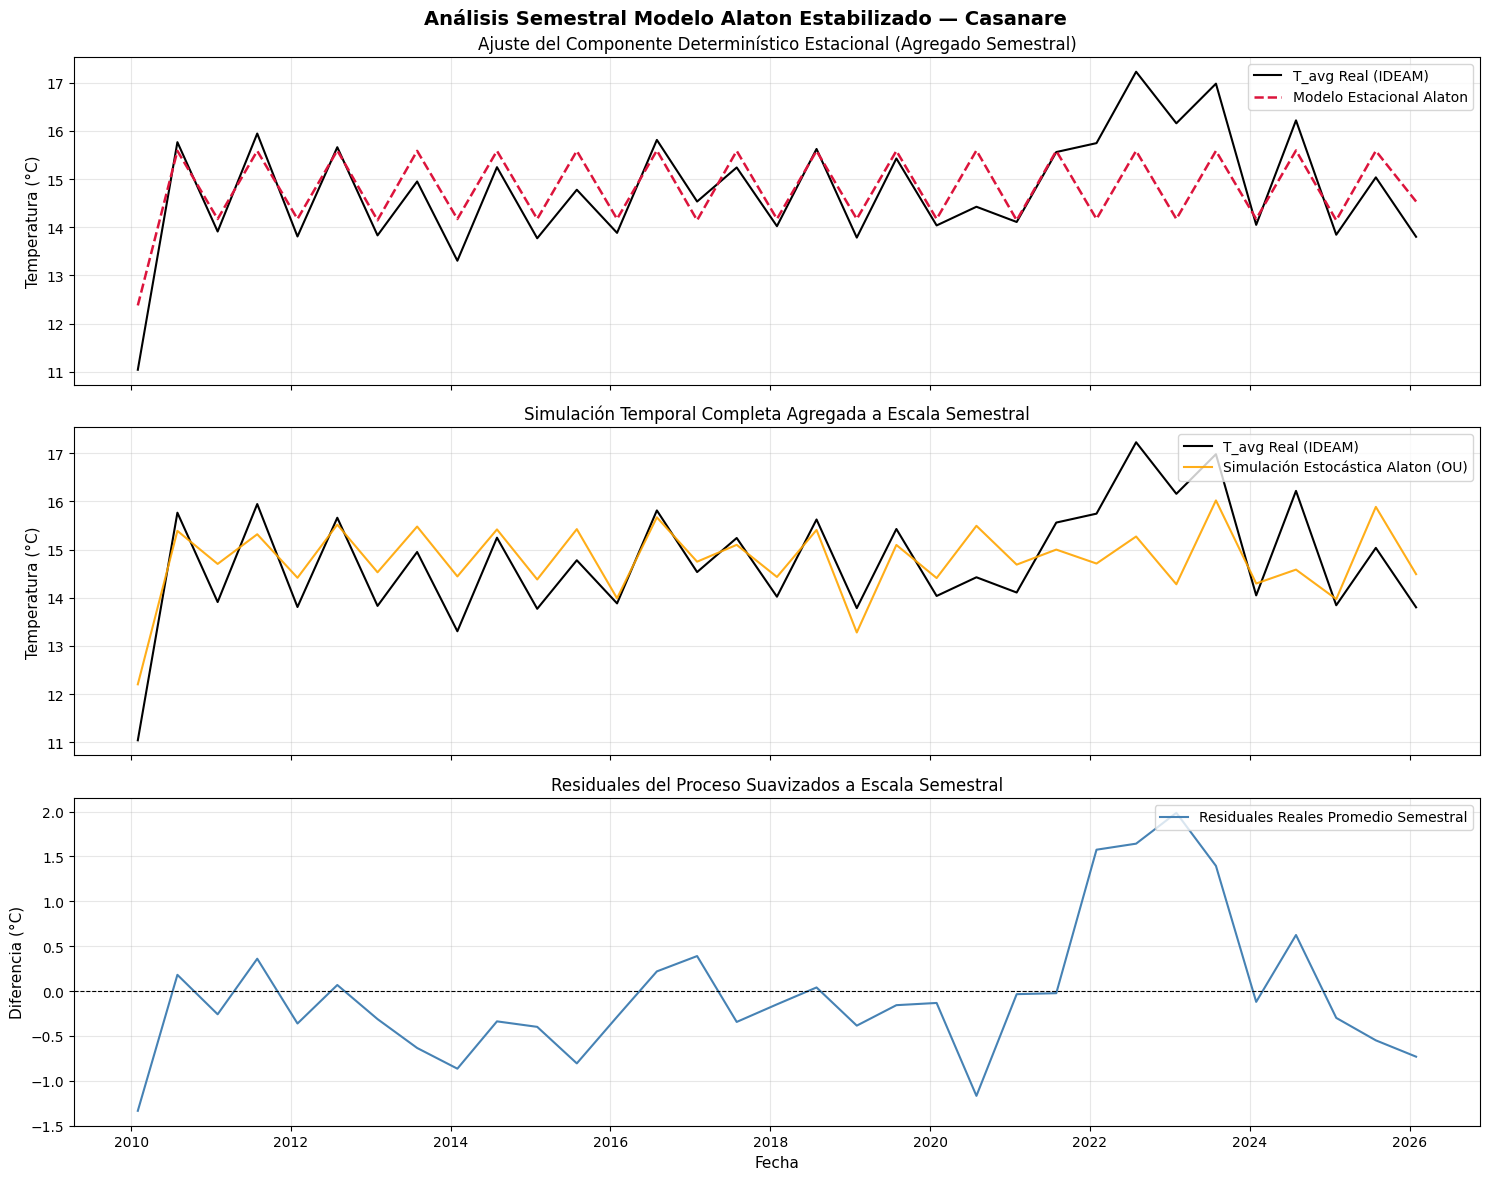


 EJECUTANDO MODELO ALATON (SEMESTRAL) PARA: TOLIMA

---> Parámetros Diarios Controlados (Tolima):
  - Coeficiente AR(1) [phi]:   0.19889
  - Velocidad de Reversión [kappa]: 1.61502
  - Volatilidad Estocástica [sigma]: 3.59339


C:\Users\jhoan\AppData\Local\Temp\ipykernel_31832\3029107435.py:66: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  temp_semestral = temp[columnas_agrupar].resample('6M').mean()


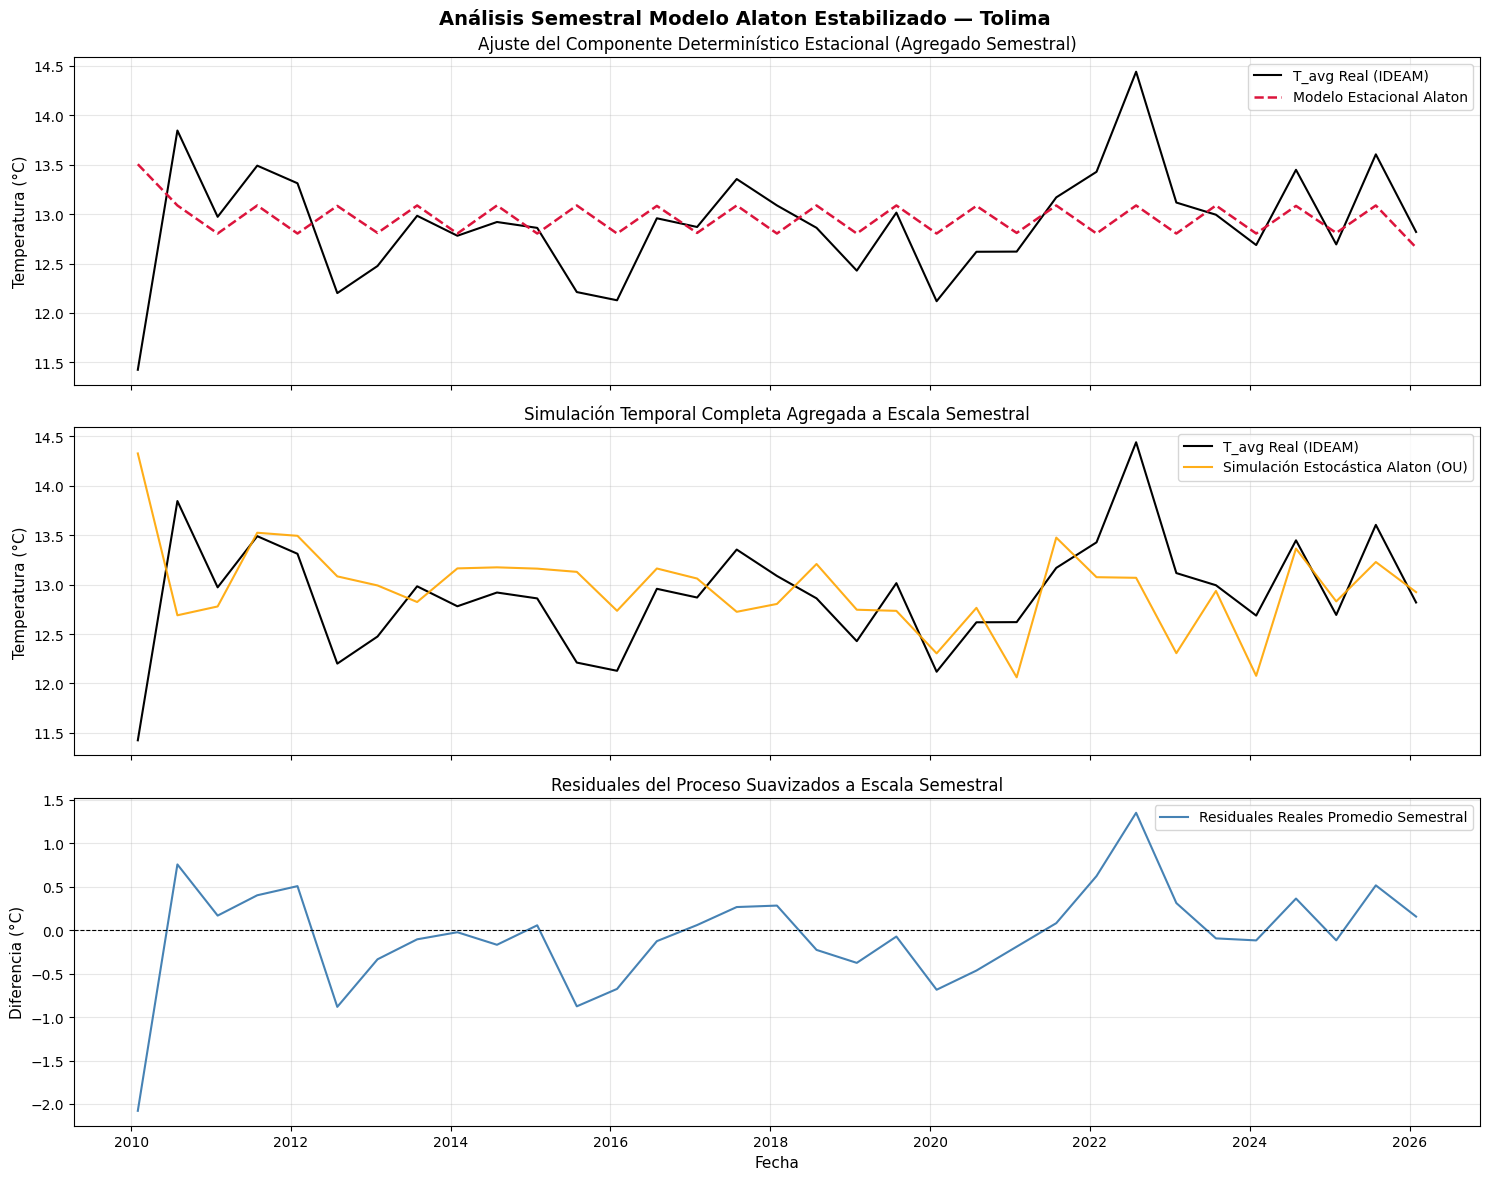

In [59]:
# =============================================================================
# FUNCIÓN MODELO ALATON SEMESTRALIZADA
# =============================================================================
def modelar_temperatura_alaton_semestral(df_dpto, nombre_dpto):
    print(f"\n" + "="*60)
    print(f" EJECUTANDO MODELO ALATON (SEMESTRAL) PARA: {nombre_dpto.upper()}")
    print("="*60)
    
    temp = df_dpto.copy()
    
    # 1. Temperatura promedio diaria
    temp['T_avg'] = (temp['Temperature_Max_C'] + temp['Temperature_Min_C']) / 2
    
    # 2. Componente estacional diario (Usa el día del año)
    dia_del_ano = temp.index.dayofyear
    temp['sin'] = np.sin(2 * np.pi * dia_del_ano / 365)
    temp['cos'] = np.cos(2 * np.pi * dia_del_ano / 365)
    
    # 3. Estimación del modelo determinístico estacional (OLS Diaria)
    y = temp['T_avg']
    X = temp[['sin', 'cos']]
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    temp['seasonal_fit'] = model.predict(X)
    temp['residuals'] = temp['T_avg'] - temp['seasonal_fit']
    
    # 4. Modelo AR(1) para residuales diarios (Proceso OU)
    temp['res_lag'] = temp['residuals'].shift(1)
    ou_data = temp.dropna().copy()
    
    y_ou = ou_data['residuals']
    X_ou = sm.add_constant(ou_data['res_lag'])
    
    ou_model = sm.OLS(y_ou, X_ou).fit()
    
    # 5. Parámetros diarios estructurados con control de estabilidad
    phi = ou_model.params['res_lag']
    
    if phi >= 0.99:
        phi = 0.95
        print("  [INFO] Coeficiente AR(1) al límite de estabilidad. Ajustado a 0.95 para garantizar convergencia.")
        
    kappa = -np.log(phi) if phi > 0 else np.nan
    sigma = np.std(ou_model.resid)
    
    print(f"\n---> Parámetros Diarios Controlados ({nombre_dpto}):")
    print(f"  - Coeficiente AR(1) [phi]:   {phi:.5f}")
    print(f"  - Velocidad de Reversión [kappa]: {kappa:.5f}")
    print(f"  - Volatilidad Estocástica [sigma]: {sigma:.5f}")
    
    # 6. SIMULACIÓN DIARIA CONTROLADA
    n = len(temp)
    sim_residuals = np.zeros(n)
    
    for t in range(1, n):
        sim_residuals[t] = phi * sim_residuals[t-1] + np.random.normal(0, sigma)
    
    temp['T_sim_diaria'] = temp['seasonal_fit'] + sim_residuals
    
    # =============================================================================
    # PASO CLAVE: AGREGACIÓN A ESCALA SEMESTRAL
    # =============================================================================
    # '6M' agrupa en bloques fijos de 6 meses cerrados
    columnas_agrupar = ['T_avg', 'seasonal_fit', 'T_sim_diaria', 'residuals']
    temp_semestral = temp[columnas_agrupar].resample('6M').mean()
    
    # 7. Gráficas integradas en escala semestral
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    fig.suptitle(f'Análisis Semestral Modelo Alaton Estabilizado — {nombre_dpto}', fontsize=14, fontweight='bold')
    
    # Panel superior: Ajuste estacional semestralizado
    axes[0].plot(temp_semestral.index, temp_semestral['T_avg'], label='T_avg Real (IDEAM)', color='black', lw=1.5)
    axes[0].plot(temp_semestral.index, temp_semestral['seasonal_fit'], label='Modelo Estacional Alaton', color='crimson', lw=1.8, ls='--')
    axes[0].set_ylabel('Temperatura (°C)', fontsize=11)
    axes[0].set_title('Ajuste del Componente Determinístico Estacional (Agregado Semestral)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper right')
    
    # Panel intermedio: Simulación Estocástica Semestralizada vs Real
    axes[1].plot(temp_semestral.index, temp_semestral['T_avg'], label='T_avg Real (IDEAM)', color='black', lw=1.5)
    axes[1].plot(temp_semestral.index, temp_semestral['T_sim_diaria'], label='Simulación Estocástica Alaton (OU)', color='orange', lw=1.5, alpha=0.9)
    axes[1].set_ylabel('Temperatura (°C)', fontsize=11)
    axes[1].set_title('Simulación Temporal Completa Agregada a Escala Semestral', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper right')
    
    # Panel 3: Residuales Semestralizados
    axes[2].plot(temp_semestral.index, temp_semestral['residuals'], color='steelblue', lw=1.5, label='Residuales Reales Promedio Semestral')
    axes[2].axhline(0, color='black', ls='--', lw=0.8)
    axes[2].set_xlabel('Fecha', fontsize=11)
    axes[2].set_ylabel('Diferencia (°C)', fontsize=11)
    axes[2].set_title('Residuales del Proceso Suavizados a Escala Semestral', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    parametros = {'phi': phi, 'kappa': kappa, 'sigma': sigma}
    return temp_semestral, parametros

# =============================================================================
# EJECUCIÓN 
# =============================================================================
df_s_casanare, p_casanare = modelar_temperatura_alaton_semestral(df_Casanare, "Casanare")
df_s_tolima,   p_tolima   = modelar_temperatura_alaton_semestral(df_Tolima, "Tolima")

# FUNCIÓN DE ALATÓN DE ACUERDO A LA TEMPORALIDAD PREFERIDA

In [60]:
# =============================================================================
# FUNCIÓN UNIFICADA: MODELO ALATON MULTI-ESCALA TEMPORAL
# =============================================================================
def modelar_temperatura_alaton(df_dpto, nombre_dpto, frecuencia='mensual'):
    """
    Ejecuta el pipeline completo del modelo Alaton calibrado a nivel diario,
    y agrega dinámicamente los resultados a la escala temporal seleccionada.
    
    Opciones de frecuencia: 'diaria', 'mensual', 'trimestral', 'semestral', 'anual'
    """
    # Mapeo de frecuencias amigables a códigos oficiales de pandas resample (2026+)
    mapa_frecuencias = {
        'diaria': 'D',
        'mensual': 'ME',
        'trimestral': 'QE',
        'semestral': '6ME',
        'anual': 'YE'
    }
    
    frec_code = mapa_frecuencias.get(frecuencia.lower())
    if frec_code is None:
        raise ValueError("Frecuencia no válida. Elige entre: 'diaria', 'mensual', 'trimestral', 'semestral', 'anual'")
        
    print(f"\n" + "="*75)
    print(f" EJECUTANDO MODELO ALATON (ESCALA: {frecuencia.upper()}) PARA: {nombre_dpto.upper()}")
    print("="*75)
    
    temp = df_dpto.copy()
    
    # 1. Temperatura promedio diaria
    temp['T_avg'] = (temp['Temperature_Max_C'] + temp['Temperature_Min_C']) / 2
    
    # 2. Componente estacional diario (Usa el día del año para consistencia de 365 días)
    dia_del_ano = temp.index.dayofyear
    temp['sin'] = np.sin(2 * np.pi * dia_del_ano / 365)
    temp['cos'] = np.cos(2 * np.pi * dia_del_ano / 365)
    
    # 3. Estimación del modelo determinístico estacional (OLS Diaria)
    y = temp['T_avg']
    X = sm.add_constant(temp[['sin', 'cos']])
    
    model = sm.OLS(y, X).fit()
    temp['seasonal_fit'] = model.predict(X)
    temp['residuals'] = temp['T_avg'] - temp['seasonal_fit']
    
    # 4. Modelo AR(1) para residuales diarios (Proceso Ornstein-Uhlenbeck)
    temp['res_lag'] = temp['residuals'].shift(1)
    ou_data = temp.dropna().copy()
    
    y_ou = ou_data['residuals']
    X_ou = sm.add_constant(ou_data['res_lag'])
    
    ou_model = sm.OLS(y_ou, X_ou).fit()
    
    # 5. Parámetros diarios estructurados con control de estabilidad
    phi = ou_model.params['res_lag']
    if phi >= 0.99:
        phi = 0.95
        print("  [INFO] Coeficiente AR(1) al límite de estabilidad. Ajustado a 0.95 para garantizar convergencia.")
        
    kappa = -np.log(phi) if phi > 0 else np.nan
    sigma = np.std(ou_model.resid)
    
    print(f"\n---> Parámetros Diarios Calibrados ({nombre_dpto}):")
    print(f"  - Coeficiente AR(1) [phi]:       {phi:.5f}")
    print(f"  - Velocidad de Reversión [kappa]: {kappa:.5f}")
    print(f"  - Volatilidad Estocástica [sigma]: {sigma:.5f}")
    
    # 6. Simulación diaria base
    n = len(temp)
    sim_residuals = np.zeros(n)
    for t in range(1, n):
        sim_residuals[t] = phi * sim_residuals[t-1] + np.random.normal(0, sigma)
        
    temp['T_sim_diaria'] = temp['seasonal_fit'] + sim_residuals
    
    # =============================================================================
    # PASO CLAVE: AGREGACIÓN DINÁMICA A LA FRECUENCIA SOLICITADA
    # =============================================================================
    columnas_agrupar = ['T_avg', 'seasonal_fit', 'T_sim_diaria', 'residuals']
    temp_agregada = temp[columnas_agrupar].resample(frec_code).mean()
    
    # 7. Gráficas integradas adaptadas a la escala temporal
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    fig.suptitle(f'Análisis Estructural Modelo Alaton ({frecuencia.capitalize()}) — {nombre_dpto}', fontsize=14, fontweight='bold')
    
    # Panel superior: Ajuste estacional agregado
    axes[0].plot(temp_agregada.index, temp_agregada['T_avg'], label='T_avg Real (IDEAM)', color='black', lw=1.5)
    axes[0].plot(temp_agregada.index, temp_agregada['seasonal_fit'], label='Modelo Estacional Alaton', color='crimson', lw=1.8, ls='--')
    axes[0].set_ylabel('Temperatura (°C)', fontsize=11)
    axes[0].set_title(f'Ajuste del Componente Determinístico Estacional (Agregado {frecuencia.capitalize()})', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper right')
    
    # Panel intermedio: Simulación Estocástica agregada vs Real
    axes[1].plot(temp_agregada.index, temp_agregada['T_avg'], label='T_avg Real (IDEAM)', color='black', lw=1.5)
    axes[1].plot(temp_agregada.index, temp_agregada['T_sim_diaria'], label='Simulación Estocástica Alaton (OU)', color='orange', lw=1.5, alpha=0.9)
    axes[1].set_ylabel('Temperatura (°C)', fontsize=11)
    axes[1].set_title(f'Simulación Temporal Completa Agregada a Escala {frecuencia.capitalize()}', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper right')
    
    # Panel inferior: Residuales agregados
    axes[2].plot(temp_agregada.index, temp_agregada['residuals'], color='steelblue', lw=1.5, label=f'Residuales Reales Promedio {frecuencia.capitalize()}')
    axes[2].axhline(0, color='black', ls='--', lw=0.8)
    axes[2].set_xlabel('Fecha', fontsize=11)
    axes[2].set_ylabel('Diferencia (°C)', fontsize=11)
    axes[2].set_title(f'Residuales del Proceso Suavizados a Escala {frecuencia.capitalize()}', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    parametros = {'phi': phi, 'kappa': kappa, 'sigma': sigma, 'frecuencia_salida': frecuencia}
    return temp_agregada, parametros


 EJECUTANDO MODELO ALATON (ESCALA: TRIMESTRAL) PARA: TOLIMA

---> Parámetros Diarios Calibrados (Tolima):
  - Coeficiente AR(1) [phi]:       0.19889
  - Velocidad de Reversión [kappa]: 1.61502
  - Volatilidad Estocástica [sigma]: 3.59339


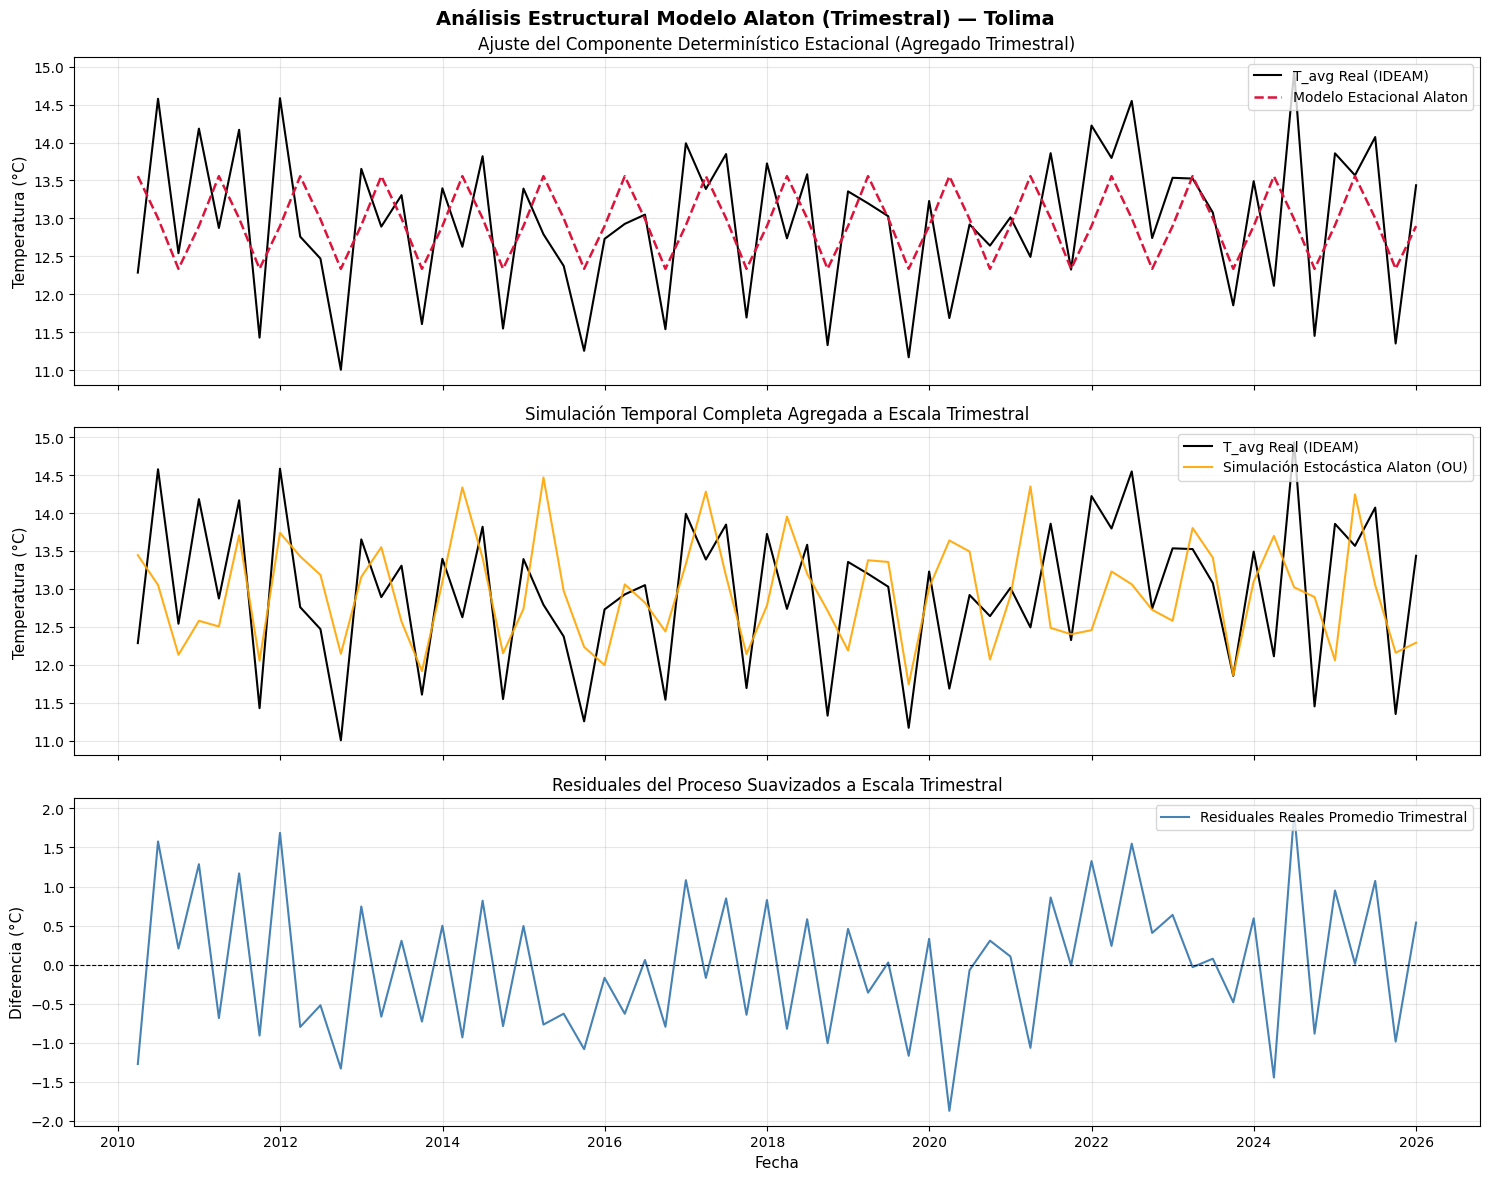


 EJECUTANDO MODELO ALATON (ESCALA: TRIMESTRAL) PARA: CASANARE

---> Parámetros Diarios Calibrados (Casanare):
  - Coeficiente AR(1) [phi]:       0.08132
  - Velocidad de Reversión [kappa]: 2.50938
  - Volatilidad Estocástica [sigma]: 4.67690


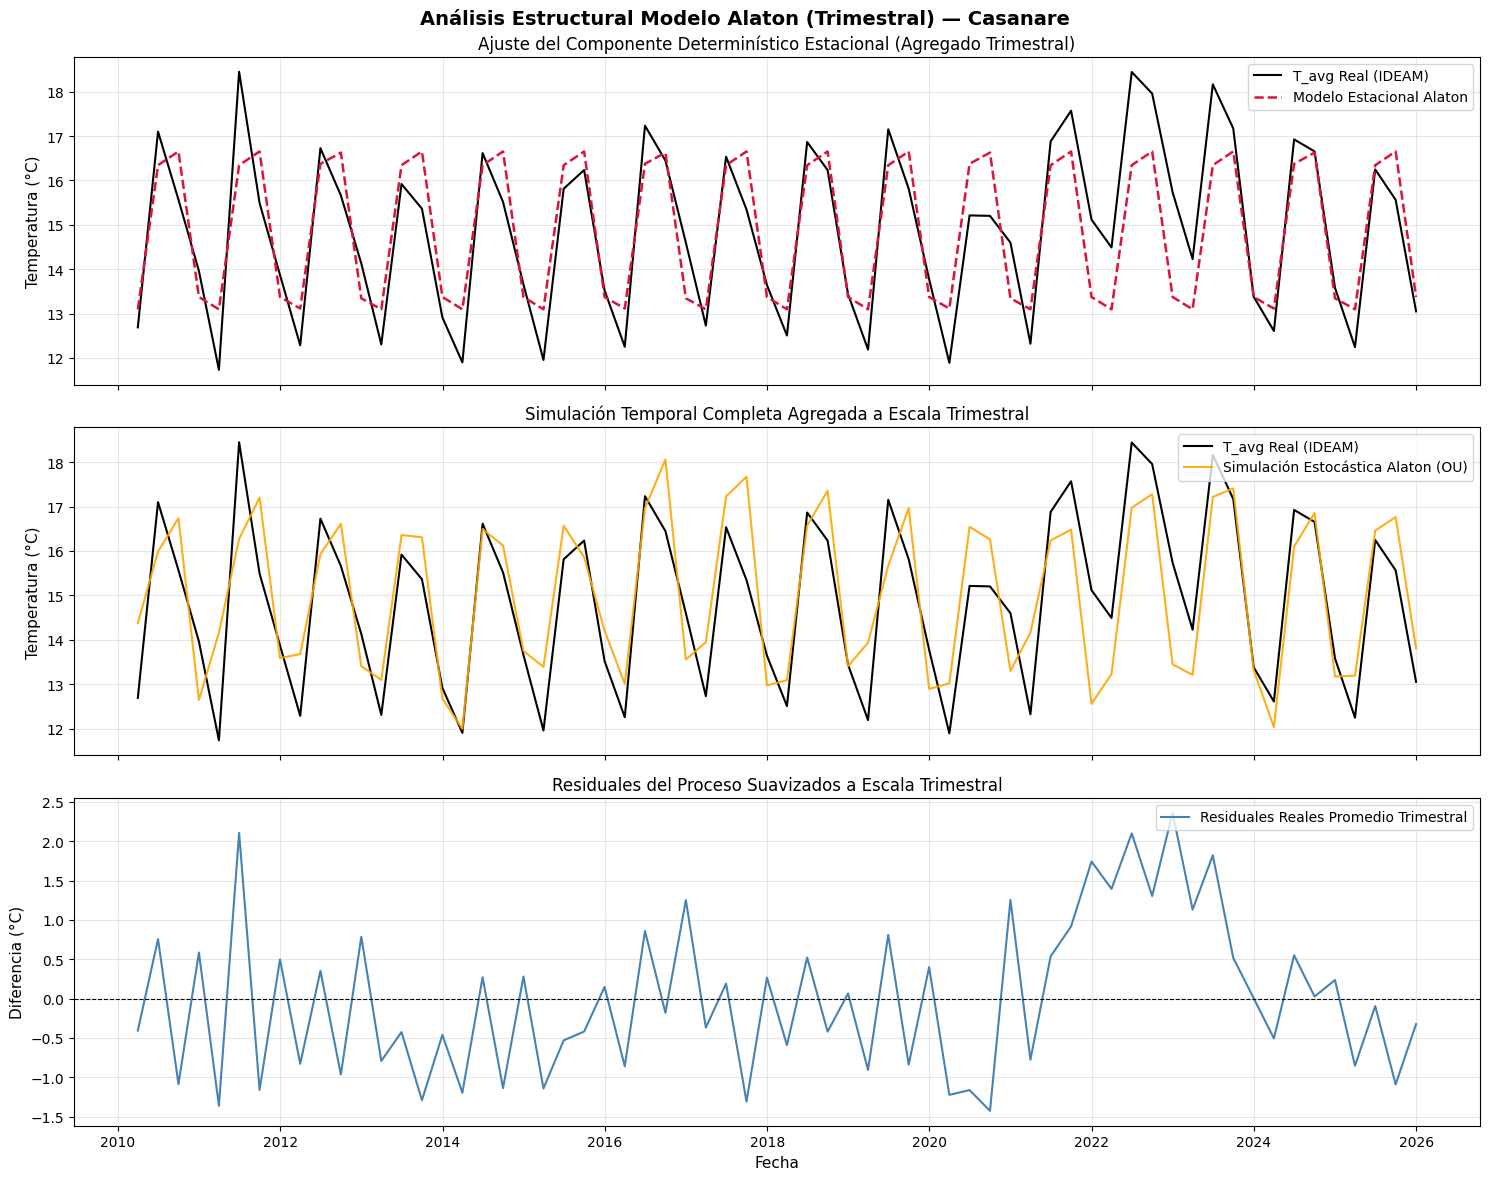

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Leer el excel
df = pd.read_excel('../data/processed/Modelo_Completo.xlsx')

# Renombrar columnas para ajustar a formato requerido
df.rename(
    columns={
        't_min': 'Temperature_Min_C',
        't_max': 'Temperature_Max_C',
        'precip': 'Precipitation_mm',
        'date': 'Date',
        "t_mean": "Temperature_Avg_C",
    },
    inplace=True,
)

# 1. Asegurar que la columna de fecha sea datetime desde el inicio
df['Date'] = pd.to_datetime(df['Date'])

# 2. Filtrar los departamentos seleccionando solo las columnas requeridas y definiendo la fecha como índice
columnas_interes = ['Temperature_Avg_C', 'Temperature_Min_C', 'Temperature_Max_C', 'Precipitation_mm']

df_Casanare = df[df['department'] == 'Casanare'].set_index('Date')[columnas_interes].copy()
df_Tolima   = df[df['department'] == 'Tolima'].set_index('Date')[columnas_interes].copy()

# 3. Ver primeros registros 
print("--- Casanare ---")
print(df_Casanare.head())

print("\n--- Tolima ---")
print(df_Tolima.head())

# Ejemplo 1: Simulación y análisis trimestral para Tolima
df_trimestral_tol, p_tol = modelar_temperatura_alaton(df_Tolima, "Tolima", frecuencia='trimestral')

# Ejemplo 2: Simulación y análisis Trimestral para Casanare
df_trimestral_cas, p_cas = modelar_temperatura_alaton(df_Casanare, "Casanare", frecuencia='trimestral')
